In [550]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**numpy** is used for calculations, **pandas** for handling data, **seaborn** for creating beautiful plots, and **matplotlib.pyplot** for customizing and displaying graphs.

In [552]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Descriptive Analytics

In [554]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**.head()** - used for print first five rows

In [556]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [557]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [558]:
cat_columns = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status","hypertension"]
for i in cat_columns:
  print(i,":")
  for j in np.unique(np.array(df[i])):
    print(j,":",list(df[i]).count(j))

gender :
Female : 2994
Male : 2115
Other : 1
ever_married :
No : 1757
Yes : 3353
work_type :
Govt_job : 657
Never_worked : 22
Private : 2925
Self-employed : 819
children : 687
Residence_type :
Rural : 2514
Urban : 2596
smoking_status :
Unknown : 1544
formerly smoked : 885
never smoked : 1892
smokes : 789
hypertension :
0 : 4612
1 : 498


**.tail()** - used for print last five rows

In [560]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**.info()** method provides a concise summary of a DataFrame, including the number of rows, columns, non-null values, data types of each column, and memory usage, helping to quickly understand the structure and quality of the data.

In [562]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [563]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

**.describe()** method gives a summary of numbers in a DataFrame, like how many values there are, the average, how spread out the numbers are, the smallest and largest values, and middle ranges. This function helps to quickly get a sense of the distribution, central tendency, and spread of the data. It also highlights potential outliers and gives an overview of the dataset's structure.

- **avg_glucose_level**: The max value of `271.74` could be an outlier.
- **bmi**: The max value of `97.6` is extremely high and may be an outlier.

In [565]:
print("Attribute: gender")
gender_counts = df["gender"].value_counts()
gender_percentages = df["gender"].value_counts(normalize=True) * 100
gender_summary = pd.DataFrame({"Count": gender_counts, "Percentage (%)": gender_percentages})
print(gender_summary)

Attribute: gender
        Count  Percentage (%)
gender                       
Female   2994       58.590998
Male     2115       41.389432
Other       1        0.019569


In [566]:
df['age'].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [567]:
age_bins = [12, 18, 25, 32, 40, 50, 60, float('inf')]
age_labels = ['12-18', '19-25', '26-32', '33-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
age_group_count = df['age_group'].value_counts()
age_group_count_sorted = age_group_count.sort_index(ascending=True)
total_count = len(df)
print(age_group_count_sorted)
print("\nTotal :", total_count)

age_group
12-18     313
19-25     380
26-32     413
33-40     521
40-50     730
50-60     834
60+      1376
Name: count, dtype: int64

Total : 5110


In [568]:
df.drop(columns=['age_group'], inplace=True)

In [569]:
print("Attribute: hypertension")
hypertension_counts = df["hypertension"].value_counts()
hypertension_percentages = df["hypertension"].value_counts(normalize=True) * 100
hypertension_summary = pd.DataFrame({"Count": hypertension_counts, "Percentage (%)": hypertension_percentages})
print(hypertension_summary)

Attribute: hypertension
              Count  Percentage (%)
hypertension                       
0              4612       90.254403
1               498        9.745597


In [570]:
print("Attribute: heart disease")
heart_disease_counts = df["heart_disease"].value_counts()
heart_disease_percentages = df["heart_disease"].value_counts(normalize=True) * 100
heart_disease_summary = pd.DataFrame({"Count": heart_disease_counts, "Percentage (%)": heart_disease_percentages})
print(heart_disease_summary)

Attribute: heart disease
               Count  Percentage (%)
heart_disease                       
0               4834       94.598826
1                276        5.401174


In [571]:
print("Attribute: Ever married")
ever_married_counts = df["ever_married"].value_counts()
ever_married_percentages = df["ever_married"].value_counts(normalize=True) * 100
ever_married_summary = pd.DataFrame({"Count": ever_married_counts, "Percentage (%)": ever_married_percentages})
print(ever_married_summary)

Attribute: Ever married
              Count  Percentage (%)
ever_married                       
Yes            3353       65.616438
No             1757       34.383562


In [572]:
print("Attribute: work type")
work_type_counts = df["work_type"].value_counts()
work_type_percentages = df["work_type"].value_counts(normalize=True) * 100
work_type_summary = pd.DataFrame({"Count": work_type_counts, "Percentage (%)": work_type_percentages})
print(work_type_summary)

Attribute: work type
               Count  Percentage (%)
work_type                           
Private         2925       57.240705
Self-employed    819       16.027397
children         687       13.444227
Govt_job         657       12.857143
Never_worked      22        0.430528


In [573]:
print("Attribute: Residence type")
Residence_type_counts = df["Residence_type"].value_counts()
Residence_type_percentages = df["Residence_type"].value_counts(normalize=True) * 100
Residence_type_summary = pd.DataFrame({"Count": Residence_type_counts, "Percentage (%)": Residence_type_percentages})
print(Residence_type_summary)

Attribute: Residence type
                Count  Percentage (%)
Residence_type                       
Urban            2596       50.802348
Rural            2514       49.197652


In [574]:
df['avg_glucose_level'].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [575]:
df['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [576]:
print("Attribute: smoking status")
smoking_status_counts = df["smoking_status"].value_counts()
smoking_status_percentages = df["smoking_status"].value_counts(normalize=True) * 100
smoking_status_summary = pd.DataFrame({"Count": smoking_status_counts, "Percentage (%)": smoking_status_percentages})
print(smoking_status_summary)

Attribute: smoking status
                 Count  Percentage (%)
smoking_status                        
never smoked      1892       37.025440
Unknown           1544       30.215264
formerly smoked    885       17.318982
smokes             789       15.440313


In [577]:
print("Attribute: stroke")
stroke_counts = df["stroke"].value_counts()
stroke_percentages = df["stroke"].value_counts(normalize=True) * 100
stroke_summary = pd.DataFrame({"Count": stroke_counts, "Percentage (%)": stroke_percentages})
print(stroke_summary)

Attribute: stroke
        Count  Percentage (%)
stroke                       
0        4861       95.127202
1         249        4.872798


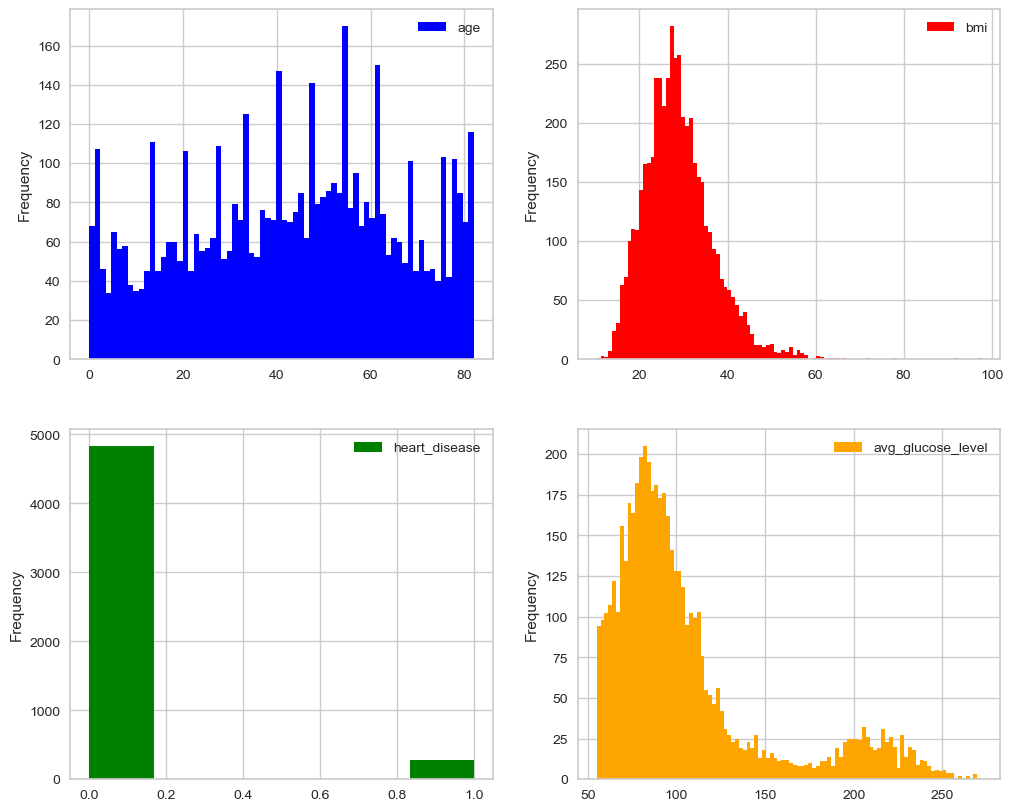

In [578]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
df.plot(kind="hist", y="age", bins=70, color="blue", ax=axes[0][0])
df.plot(kind="hist", y="bmi", bins=100, color="red", ax=axes[0][1])
df.plot(kind="hist", y="heart_disease", bins=6, color="green", ax=axes[1][0])
df.plot(kind="hist", y="avg_glucose_level", bins=100, color="orange", ax=axes[1][1])
plt.show()

Code generates a grid of histograms to visualize the distribution of specific columns (features) in the dataset.

In [580]:
print("Columns : " , df.shape[1])
print ("Rows : " , df.shape[0])

Columns :  12
Rows :  5110


The code counts and displays the total number of rows and columns in the dataset.

In [582]:
print("Features : " , df.columns.tolist())

Features :  ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


displays all the column names (features) in the dataset as a list.

In [584]:
print("Unique Values :\n ",df.nunique())

Unique Values :
  id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64


the number of unique values in each column of the DataFrame.



In [586]:
print("\nMissing Values : ", df.isnull().sum().values.sum())


Missing Values :  201


This code counts and prints the total number of missing values in a DataFrame.

### Checking Missing Values

In [589]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

The bmi column has **201** missing values.

### Identify Outliers
- **avg_glucose_level**: The max value of `271.74` could be an outlier.
- **bmi**: The max value of `97.6` is extremely high and may be an outlier.

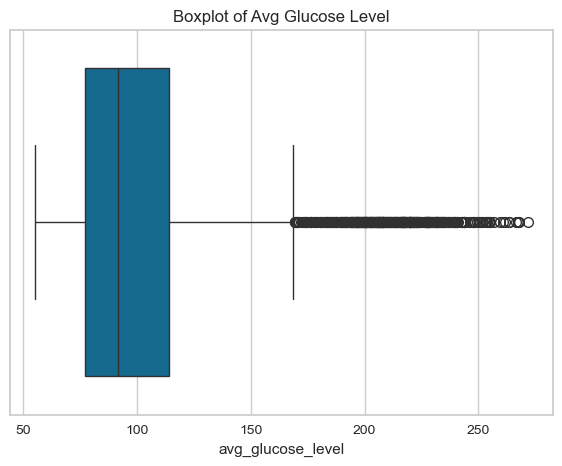

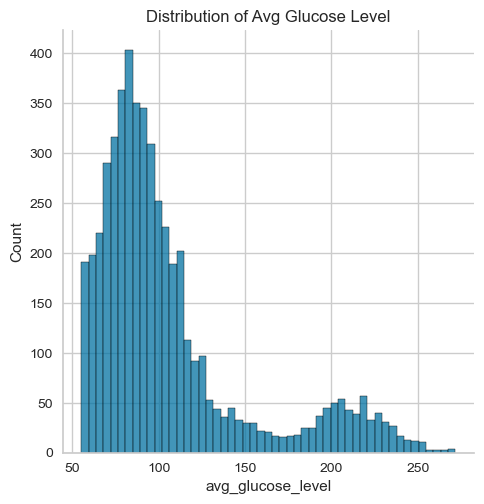

In [592]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='avg_glucose_level')
plt.title('Boxplot of Avg Glucose Level')
plt.show()

sns.displot(data=df, x='avg_glucose_level')
plt.title('Distribution of Avg Glucose Level')
plt.show()

* The first code creates a boxplot of average glucose levels
* second code creates a histogram showing the distribution of average glucose levels.

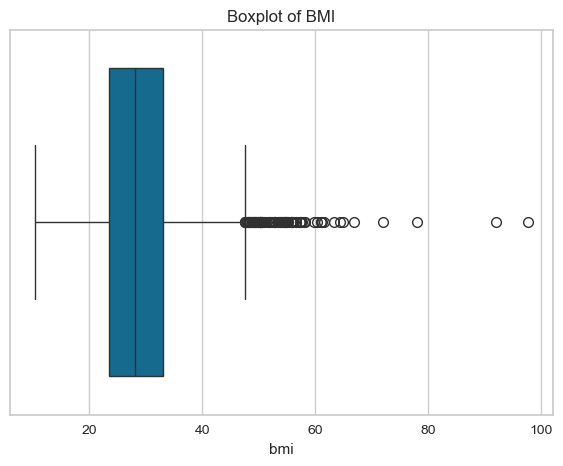

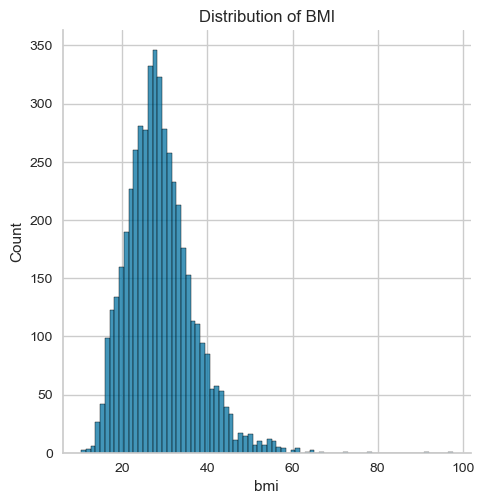

In [594]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='bmi')
plt.title('Boxplot of BMI')
plt.show()

sns.displot(data=df, x='bmi')
plt.title('Distribution of BMI')
plt.show()

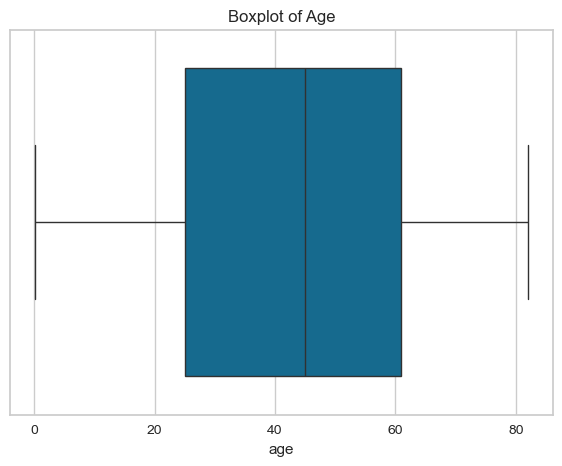

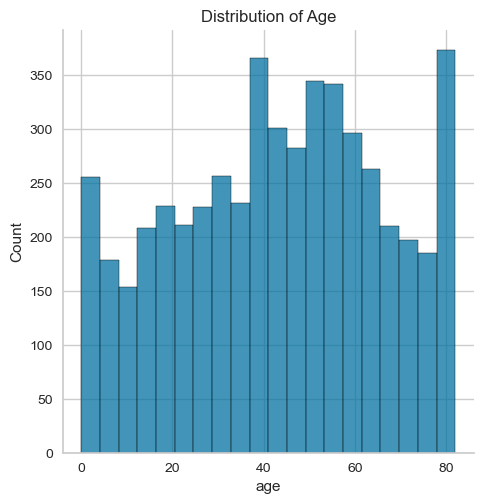

In [595]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='age')
plt.title('Boxplot of Age')
plt.show()

sns.displot(data=df, x='age')
plt.title('Distribution of Age')
plt.show()

### Visualizations

* The first code makes a boxplot of BMI
* Second code makes a histogram of BMI.

- #### Pie Plot of Stroke Cases

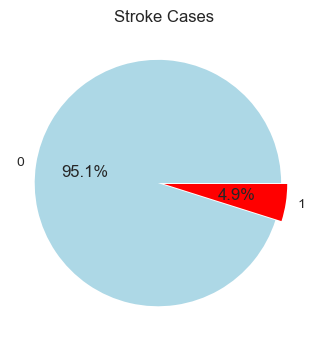

In [599]:
 labels = df['stroke'].value_counts(sort=True).index.tolist()
sizes = df['stroke'].value_counts(sort=True).values
colors = ["lightblue", "red"]
explode = (0.05, 0)
plt.figure(figsize=(4, 4))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',)
plt.title('Stroke Cases')
plt.show()

- #### Counterplot of Gender Distribution

Text(0.5, 1.0, 'Gender Distribution')

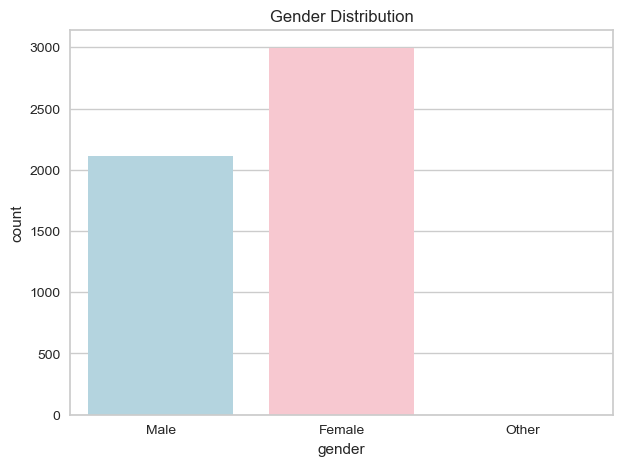

In [601]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='gender', hue='gender', palette=["lightblue", "pink", "green"])
plt.title("Gender Distribution")

- #### Scatter Plot of Age vs. Avg Glucose Level and Bmi vs. Avg_Glucose_Level



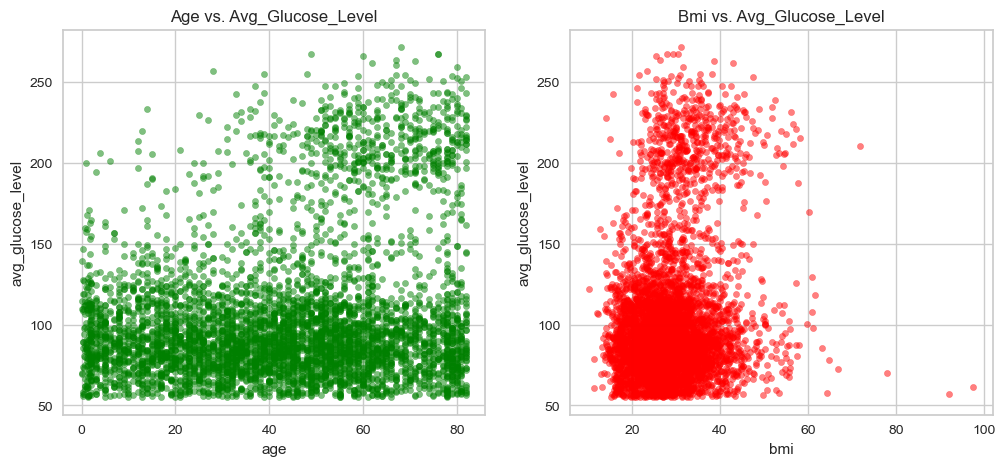

In [603]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
df.plot(kind="scatter", x="age", y="avg_glucose_level", alpha=0.5, color='green', ax=axes[0], title="Age vs. Avg_Glucose_Level")
df.plot(kind="scatter", x="bmi", y="avg_glucose_level", alpha=0.5, color='red', ax=axes[1], title="Bmi vs. Avg_Glucose_Level")
plt.show()

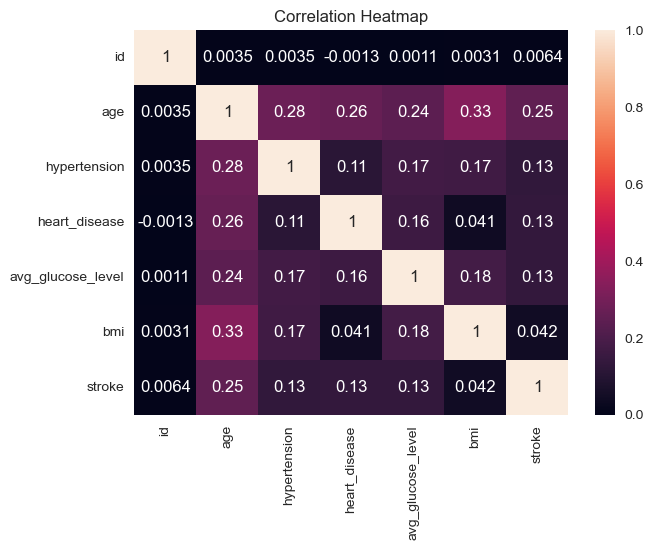

In [604]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 1.0, 'Ever Married Distribution')

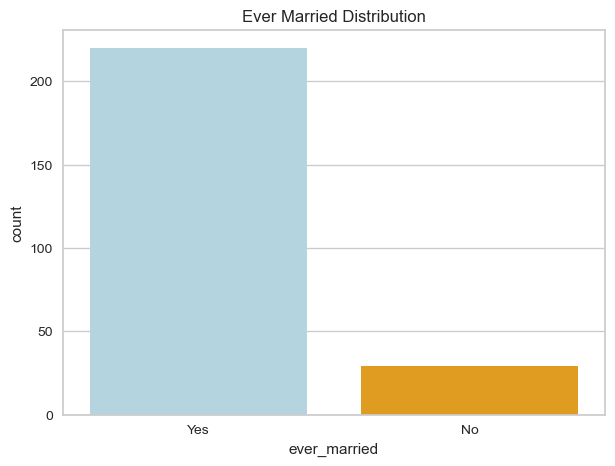

In [605]:
plt.figure(figsize=(7,5))
stroke = df.loc[df['stroke']==1]
sns.countplot(data=stroke, x = 'ever_married',hue='ever_married', palette=["lightblue", "orange"])
plt.title("Ever Married Distribution")

Text(0.5, 1.0, 'Work Type Distribution')

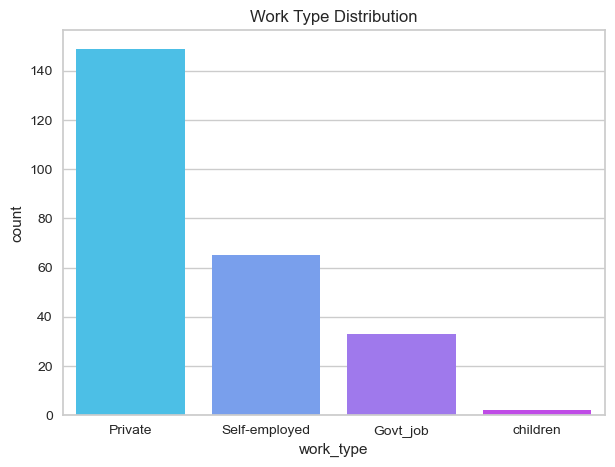

In [606]:
plt.figure(figsize=(7,5))
sns.countplot(data=stroke,x='work_type',hue='work_type',palette='cool')
plt.title("Work Type Distribution")

Text(0.5, 1.0, 'Residence Type Distribution')

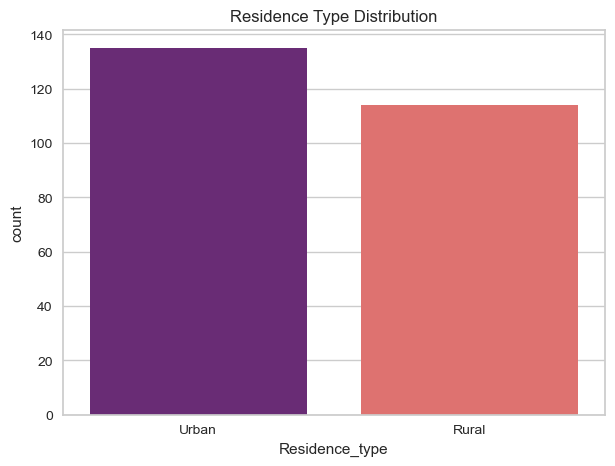

In [607]:
plt.figure(figsize=(7,5))
sns.countplot(data=stroke,x='Residence_type',hue='Residence_type',palette='magma')
plt.title("Residence Type Distribution")

Text(0.5, 1.0, 'Smoking Status Distribution')

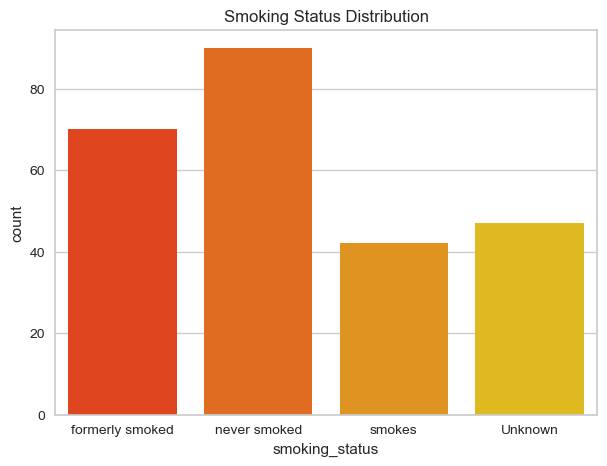

In [608]:
plt.figure(figsize=(7,5))
sns.countplot(data=stroke,x='smoking_status',hue='smoking_status',palette='autumn')
plt.title("Smoking Status Distribution")

Text(0.5, 1.0, 'Hypertension Distribution')

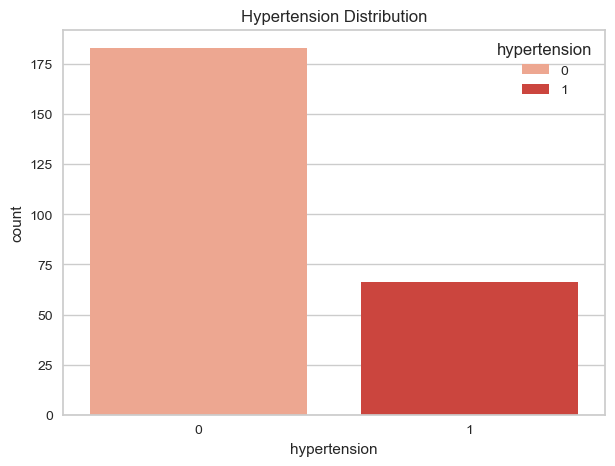

In [609]:
plt.figure(figsize=(7,5))
sns.countplot(data=stroke,x='hypertension',hue='hypertension',palette='Reds')
plt.title("Hypertension Distribution")

Text(0.5, 1.0, 'Heart Disease Distribution')

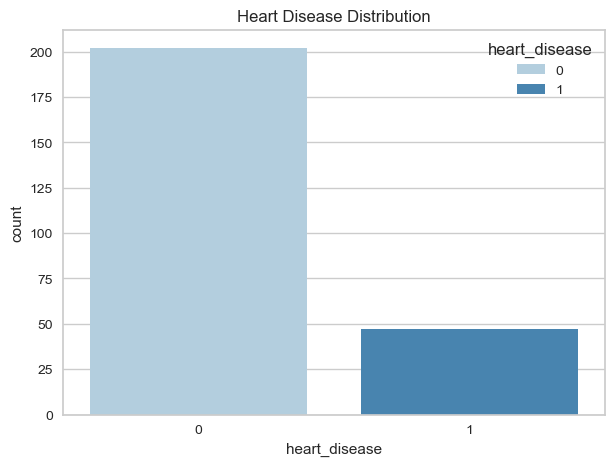

In [610]:
plt.figure(figsize=(7,5))
sns.countplot(data=stroke,x='heart_disease',hue='heart_disease',palette='Blues')
plt.title("Heart Disease Distribution")

- #### Pairplot

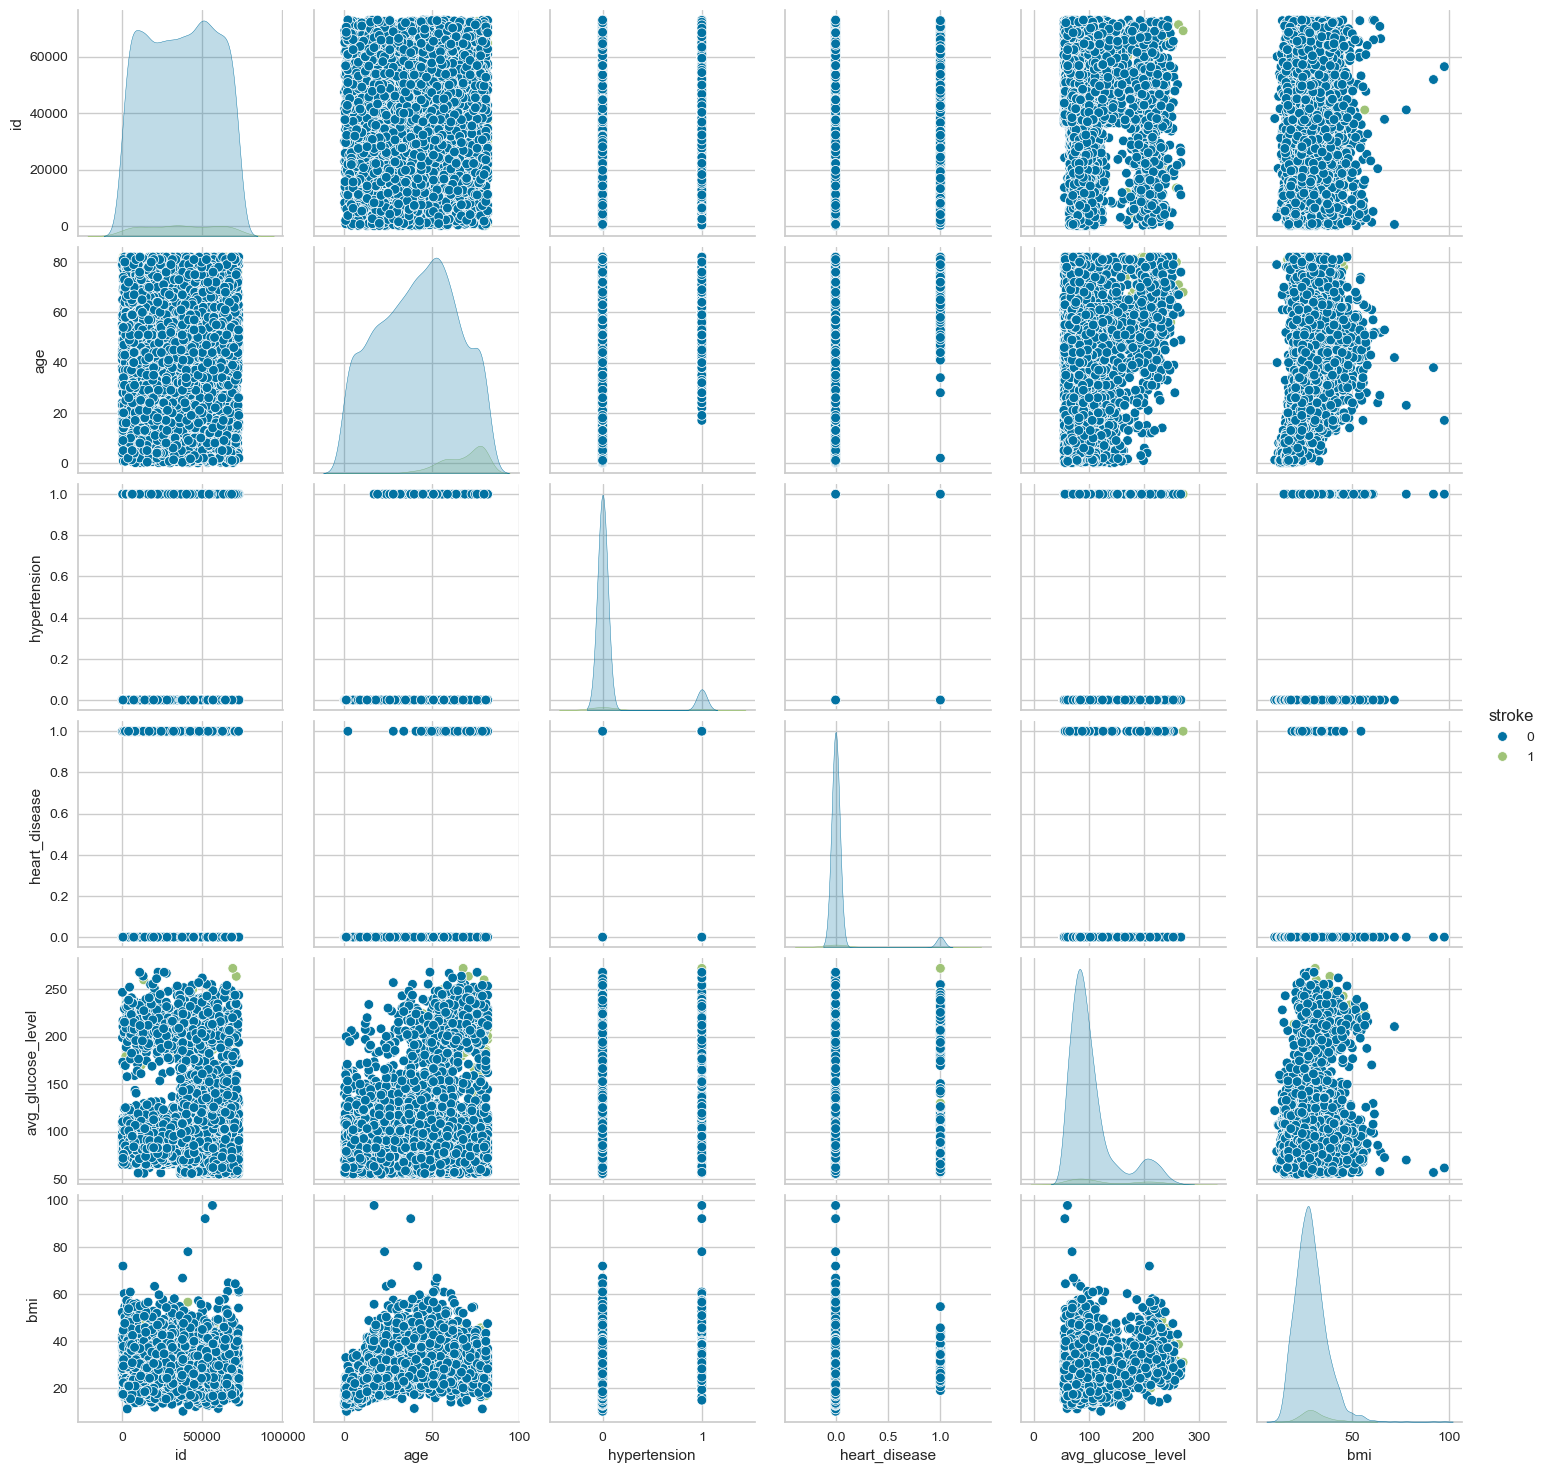

In [612]:
sns.pairplot(df, hue='stroke', diag_kind='kde')
plt.show()

# Data Preparation

### Handling Missing Values

In [615]:
df['bmi']=df['bmi'].fillna(df['bmi'].mean())
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### Handling Outliers Using IQR Method

In [617]:
def fix_outliers_iqr(column):
  q1 = column.quantile(0.25)
  q3 = column.quantile(0.75)
  iqr = q3 - q1
  lower_limit = q1 - 1.5 * iqr
  upper_limit = q3 + 1.5 * iqr



  column = column.apply(
      lambda x: lower_limit if x < lower_limit else (upper_limit if x > upper_limit else x)
      )
  return column

#### Calculating IQR for Outlier Detection

- **Q1 (25th Percentile)**: The value below which 25% of the data falls.
- **Q3 (75th Percentile)**: The value below which 75% of the data falls.
- **IQR (Interquartile Range)**: The range of the middle 50% of the data, calculated as **IQR = Q3 - Q1**.
- This helps identify outliers by defining boundaries.

#### Calculating Outlier Boundaries

- **Upper Limit**: ( Q3 + 1.5 x IQR)  
  Defines the maximum threshold for detecting outliers.

- **Lower Limit**: ( Q1 - 1.5 x IQR)  
  Defines the minimum threshold for detecting outliers.

- Values outside these boundaries are considered outliers.

<Axes: xlabel='avg_glucose_level'>

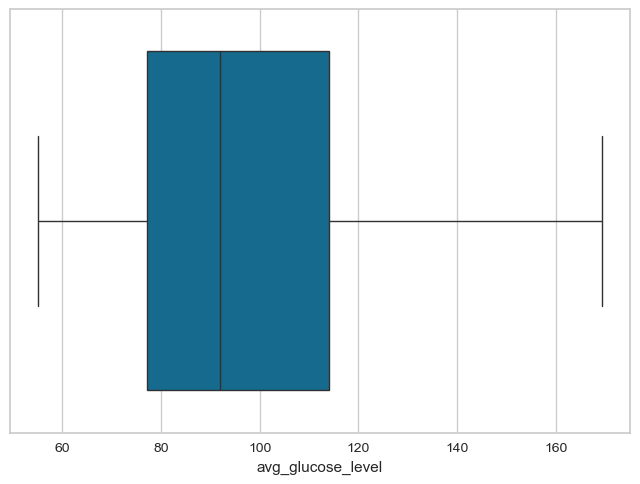

In [620]:
df['avg_glucose_level'] = fix_outliers_iqr(df['avg_glucose_level'])
sns.boxplot(data=df, x='avg_glucose_level')

<Axes: xlabel='bmi'>

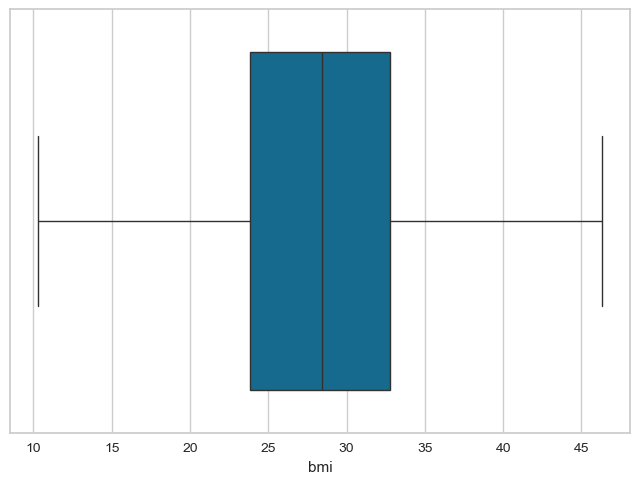

In [621]:
df['bmi'] = fix_outliers_iqr(df['bmi'])
sns.boxplot(data=df, x='bmi')

Drop Irrelevant Column

In [623]:
df.drop(columns=['id'], inplace=True)
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

This code converts the categorical columns gender, Residence_type, ever_married, work_type, and smoking_status into numeric values using the label encoder.

In [625]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['Residence_type'] = label_encoder.fit_transform(df['Residence_type'])
df['ever_married'] = label_encoder.fit_transform(df['ever_married'])
df['work_type'] = label_encoder.fit_transform(df['work_type'])
df['smoking_status'] = label_encoder.fit_transform(df['smoking_status'])

In [626]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,169.3575,36.600000,1,1
1,0,61.0,0,0,1,3,0,169.3575,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.9200,32.500000,2,1
3,0,49.0,0,0,1,2,1,169.3575,34.400000,3,1
4,0,79.0,1,0,1,3,0,169.3575,24.000000,2,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,2,1,83.7500,28.893237,2,0
5106,0,81.0,0,0,1,3,1,125.2000,40.000000,2,0
5107,0,35.0,0,0,1,3,0,82.9900,30.600000,2,0
5108,1,51.0,0,0,1,2,0,166.2900,25.600000,1,0


In [627]:
df_cl = df.copy()

"df_cl" is a copy of your DataFrame, created for performing classification tasks.

In [629]:
df_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   int32  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int32  
 5   work_type          5110 non-null   int32  
 6   Residence_type     5110 non-null   int32  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int32  
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int32(5), int64(3)
memory usage: 339.5 KB


The code given below separates the `stroke` column (which is the target variable) from the DataFrame `df_cl` to create the feature dataset `x`

In [631]:
x = df_cl.drop(columns=['stroke'],axis=1)
x.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,169.3575,36.600000,1
1,0,61.0,0,0,1,3,0,169.3575,28.893237,2
2,1,80.0,0,1,1,2,0,105.9200,32.500000,2
3,0,49.0,0,0,1,2,1,169.3575,34.400000,3
4,0,79.0,1,0,1,3,0,169.3575,24.000000,2


The code given below assign the `stroke` column into `y` from the DataFrame `df_cl` to create the `target` dataset

In [633]:
y = df_cl['stroke']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: stroke, dtype: int64

- The code applies random oversampling to balance the class distribution by increasing the number of samples in the minority class, and then prints the new class distribution.

In [635]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
oversampler = RandomOverSampler(sampling_strategy='minority')
x_over, y_over = oversampler.fit_resample(x, y)
print(Counter(y_over))

Counter({1: 4861, 0: 4861})


In [636]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
lr_model = make_pipeline(LogisticRegression(max_iter=1000))

- code creates a machine learning pipeline with a logistic regression model, using `max_iter=1000` to set the maximum number of iterations for convergence.

In [638]:
from sklearn.model_selection import train_test_split
x_train_over,x_test_over,y_train_over,y_test_over = train_test_split(x_over,y_over,test_size=0.20,random_state=42)

- Code splits the oversampled data (x_over, y_over) into training and testing sets, with 80% for training and 20% for testing, using a random seed of 42 for reproducibility.

In [640]:
lr_model.fit(x_train_over,y_train_over)

Pipeline(steps=[('logisticregression', LogisticRegression(max_iter=1000))])

- The code trains the logistic regression model (lr_model) using the oversampled training data (x_train_over and y_train_over).

In [642]:
x_train_over

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
5377,0,81.0,1,0,1,3,0,74.0200,25.000000,2
6692,1,65.0,0,0,1,3,1,68.4300,28.893237,1
4996,0,40.0,0,0,1,2,1,93.9700,23.600000,2
1561,1,62.0,1,1,1,2,1,123.9500,34.800000,1
2114,0,29.0,0,0,1,2,1,81.2000,23.000000,0
...,...,...,...,...,...,...,...,...,...,...
5734,1,70.0,1,0,1,2,0,169.3575,45.500000,1
5191,0,57.0,0,0,0,3,1,68.0200,37.500000,2
5390,1,59.0,0,0,1,2,0,169.3575,28.893237,1
860,0,46.0,0,0,1,2,0,100.1500,46.300000,3


In [643]:
x_test_over

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
1145,0,7.0,0,0,0,4,1,88.6000,17.4,0
8501,1,74.0,0,0,1,2,1,72.9600,31.3,3
3903,1,66.0,0,0,1,2,1,103.0100,33.1,2
1608,1,59.0,0,0,1,2,1,93.5800,25.1,3
9139,0,61.0,0,1,1,0,0,120.4600,36.8,3
...,...,...,...,...,...,...,...,...,...,...
6255,1,80.0,0,0,1,2,0,169.3575,31.7,3
1918,0,68.0,0,0,0,0,1,121.6600,29.1,3
9530,0,74.0,0,0,1,2,0,169.3575,34.6,1
4184,0,35.0,0,0,1,2,0,119.4000,22.9,2


In [644]:
y_train_over

5377    1
6692    1
4996    0
1561    0
2114    0
       ..
5734    1
5191    1
5390    1
860     0
7270    1
Name: stroke, Length: 7777, dtype: int64

In [645]:
y_test_over

1145    0
8501    1
3903    0
1608    0
9139    1
       ..
6255    1
1918    0
9530    1
4184    0
5953    1
Name: stroke, Length: 1945, dtype: int64

In [646]:
df_cl.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,0.414286,43.226614,0.097456,0.054012,0.656164,2.167710,0.508023,100.996204,28.721613,1.376908,0.048728
std,0.493044,22.612647,0.296607,0.226063,0.475034,1.090293,0.499985,33.214738,7.119940,1.071534,0.215320
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000
25%,0.000000,25.000000,0.000000,0.000000,0.000000,2.000000,0.000000,77.245000,23.800000,0.000000,0.000000
50%,0.000000,45.000000,0.000000,0.000000,1.000000,2.000000,1.000000,91.885000,28.400000,2.000000,0.000000
75%,1.000000,61.000000,0.000000,0.000000,1.000000,3.000000,1.000000,114.090000,32.800000,2.000000,0.000000
max,2.000000,82.000000,1.000000,1.000000,1.000000,4.000000,1.000000,169.357500,46.300000,3.000000,1.000000


In [647]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_over)
x_train_over = scaler.transform(x_train_over)
x_test_over = scaler.transform(x_test_over)

- The code standardizes the features by scaling them to have a mean of 0 and a standard deviation of 1, using the StandardScaler on both the training and test sets.

In [649]:
x_train_over

array([[-0.85516113,  1.18066939,  2.18289054, ..., -0.90891049,
        -0.67521253,  0.52824432],
       [ 1.16813918,  0.46157163, -0.45810817, ..., -1.05461936,
        -0.07377504, -0.436338  ],
       [-0.85516113, -0.66201863, -0.45810817, ..., -0.38889404,
        -0.89148822,  0.52824432],
       ...,
       [ 1.16813918,  0.19190997, -0.45810817, ...,  1.5761556 ,
        -0.07377504, -0.436338  ],
       [-0.85516113, -0.39235697, -0.45810817, ..., -0.22780623,
         2.61526755,  1.49282665],
       [-0.85516113, -0.70696224,  2.18289054, ..., -1.32414167,
         1.51844085,  1.49282665]])

In [650]:
x_test_over

array([[-0.85516113, -2.14515776, -0.45810817, ..., -0.52886839,
        -1.84928054, -1.40092032],
       [ 1.16813918,  0.86606412, -0.45810817, ..., -0.93654044,
         0.29802806,  1.49282665],
       [ 1.16813918,  0.50651524, -0.45810817, ..., -0.15325751,
         0.57609679,  0.52824432],
       ...,
       [-0.85516113,  0.86606412, -0.45810817, ...,  1.5761556 ,
         0.80782074, -0.436338  ],
       [-0.85516113, -0.88673668, -0.45810817, ...,  0.27396403,
        -0.99962606,  0.52824432],
       [-0.85516113,  0.59640246, -0.45810817, ..., -0.69829731,
        -0.350799  , -1.40092032]])

Model Creation

# Perform Classification on the "stroke"

In [653]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

- #### K Nearest Neighbors (KNN) algorithm

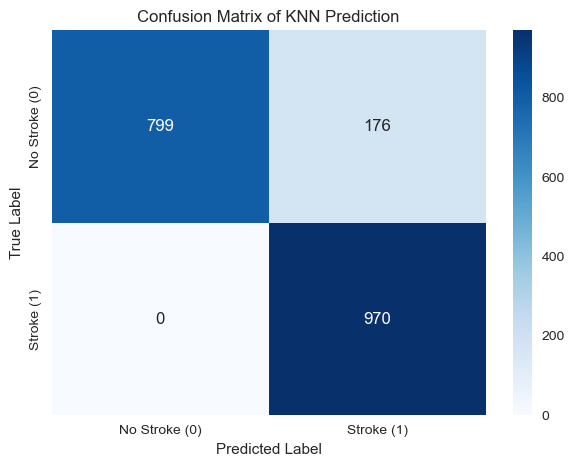

KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.82      0.90       975
           1       0.85      1.00      0.92       970

    accuracy                           0.91      1945
   macro avg       0.92      0.91      0.91      1945
weighted avg       0.92      0.91      0.91      1945


KNN Accuracy: 0.9095115681233933


In [655]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_over, y_train_over)
knn_pred = knn.predict(x_test_over)

knn_cm = confusion_matrix(y_test_over, knn_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke (0)', 'Stroke (1)'], yticklabels=['No Stroke (0)', 'Stroke (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNN Prediction')
plt.show()
knn_acc = accuracy_score(y_test_over, knn_pred)
print("KNN Classification Report:\n", classification_report(y_test_over, knn_pred, zero_division=1))
print(f"\nKNN Accuracy: {accuracy_score(y_test_over, knn_pred)}")

- #### Support Vector Machine (SVM) Algorithm

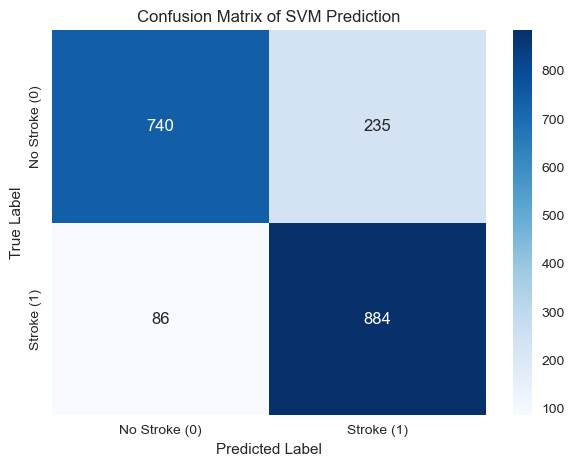

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.82       975
           1       0.79      0.91      0.85       970

    accuracy                           0.83      1945
   macro avg       0.84      0.84      0.83      1945
weighted avg       0.84      0.83      0.83      1945


SVM Accuracy: 0.834961439588689


In [657]:
svm = SVC()
svm.fit(x_train_over, y_train_over)
svm_pred = svm.predict(x_test_over)

svm_cm = confusion_matrix(y_test_over, svm_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke (0)', 'Stroke (1)'], yticklabels=['No Stroke (0)', 'Stroke (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of SVM Prediction')
plt.show()
svm_acc = accuracy_score(y_test_over, svm_pred)
print("SVM Classification Report:\n", classification_report(y_test_over, svm_pred, zero_division=1))
print(f"\nSVM Accuracy: {accuracy_score(y_test_over, svm_pred)}")

- #### Decision Trees Classifier algorithm

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98       975
           1       0.96      1.00      0.98       970

    accuracy                           0.98      1945
   macro avg       0.98      0.98      0.98      1945
weighted avg       0.98      0.98      0.98      1945

Decision Tree Accuracy: 0.9773778920308483


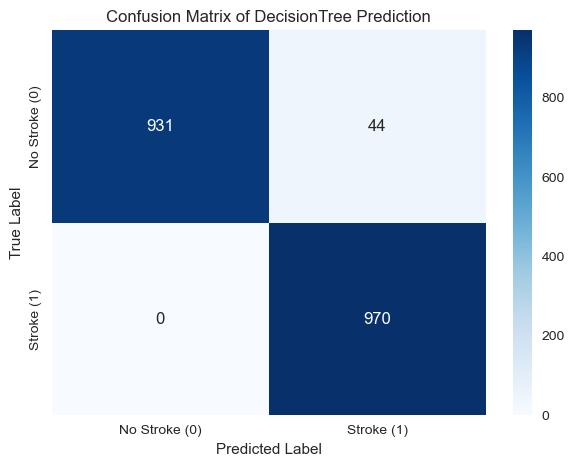

In [659]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_over, y_train_over)
dt_pred = dt.predict(x_test_over)

dt_cm = confusion_matrix(y_test_over, dt_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke (0)', 'Stroke (1)'], yticklabels=['No Stroke (0)', 'Stroke (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of DecisionTree Prediction')
plt.show
dt_acc = accuracy_score(y_test_over, dt_pred)
print("Decision Tree Classification Report:\n", classification_report(y_test_over, dt_pred, zero_division=1))
print(f"Decision Tree Accuracy: {accuracy_score(y_test_over, dt_pred)}")

- #### XGBoost Classifier algorithm

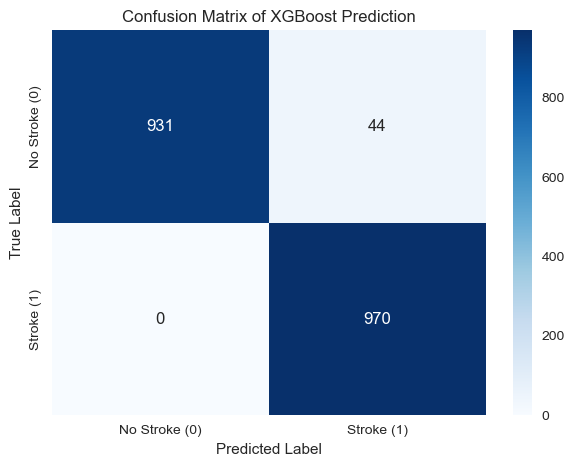

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98       975
           1       0.96      1.00      0.98       970

    accuracy                           0.98      1945
   macro avg       0.98      0.98      0.98      1945
weighted avg       0.98      0.98      0.98      1945

XGBoost Accuracy: 0.9773778920308483


In [661]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(x_train_over, y_train_over)
xgb_pred = xgb.predict(x_test_over)

xgb_cm = confusion_matrix(y_test_over, xgb_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke (0)', 'Stroke (1)'], yticklabels=['No Stroke (0)', 'Stroke (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of XGBoost Prediction')
plt.show()
xgb_acc = accuracy_score(y_test_over, xgb_pred)
print("XGBoost Classification Report:\n", classification_report(y_test_over, xgb_pred, zero_division=1))
print(f"XGBoost Accuracy: {accuracy_score(y_test_over, xgb_pred)}")

### Comparison of classifiers

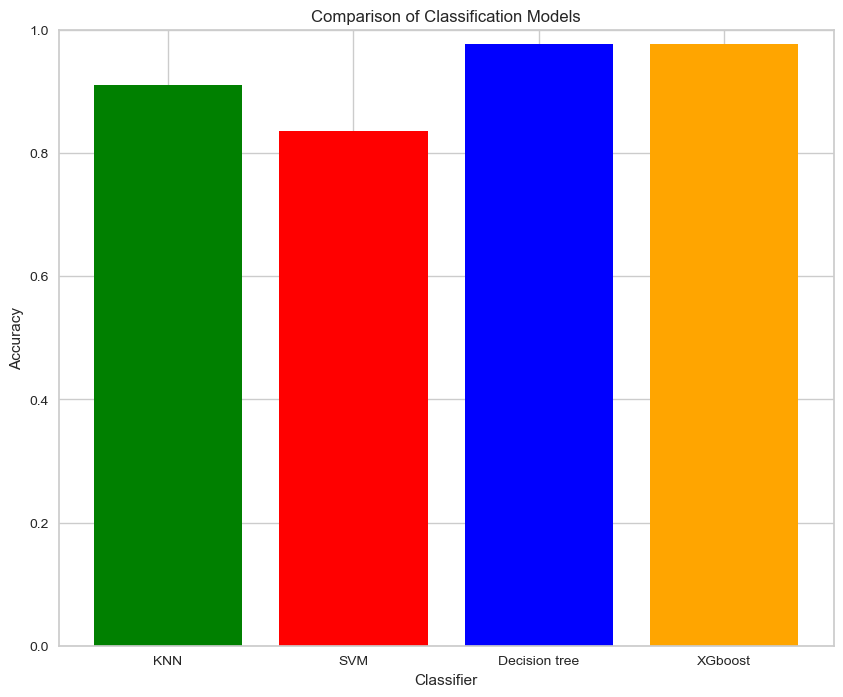

In [663]:
classifiers = ['KNN', 'SVM', 'Decision tree','XGboost',]
accuracies = [knn_acc, svm_acc, dt_acc, xgb_acc]

plt.figure(figsize=(10, 8))
plt.bar(classifiers, accuracies, color=['green', 'red', 'blue','orange'])
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Comparison of Classification Models')
plt.ylim(0, 1)
plt.show()

# Perform Regression on the 'bmi'

In [665]:
df_reg = df.copy()

In [666]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [667]:
x = df_reg.drop('bmi', axis=1)
y = df_reg['bmi']

In [668]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [669]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

- #### Support Vector Regression Algorithm

In [671]:
svr = SVR()

param_grid_svr = {
    'kernel': ['linear', 'rbf'],
    'C': [1, 10, 100],
    'epsilon': [0.1, 0.2, 0.3]
}

grid_search_svr = GridSearchCV(svr, param_grid_svr, cv=5, scoring='neg_mean_squared_error')
grid_search_svr.fit(x_train_scaled, y_train)
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(x_test_scaled)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

- #### Random Forest Regression Algorithm

In [673]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error')
grid_search_rf.fit(x_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

- #### Cross Validation

In [675]:
svr_cv = cross_val_score(best_svr, x_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
rf_cv = cross_val_score(best_rf, x_train, y_train, cv=5, scoring='neg_mean_squared_error')

- #### Results

In [677]:
print(f"SVR Performance:\nMean Squared Error: {mse_svr}\nR-squared: {r2_svr}\n")
print(f"Random Forest Performance:\nMean Squared Error: {mse_rf}\nR-squared: {r2_rf}\n")
print(f"SVR Cross-validation MSE: {np.mean(svr_cv)}")
print(f"Random Forest Cross-validation MSE: {np.mean(rf_cv)}")

SVR Performance:
Mean Squared Error: 36.39474682704818
R-squared: 0.268308017882276

Random Forest Performance:
Mean Squared Error: 35.46531652992626
R-squared: 0.2869935908187524

SVR Cross-validation MSE: -38.75917402503025
Random Forest Cross-validation MSE: -37.48937691672518


### Comparison of SVR and RandomForest

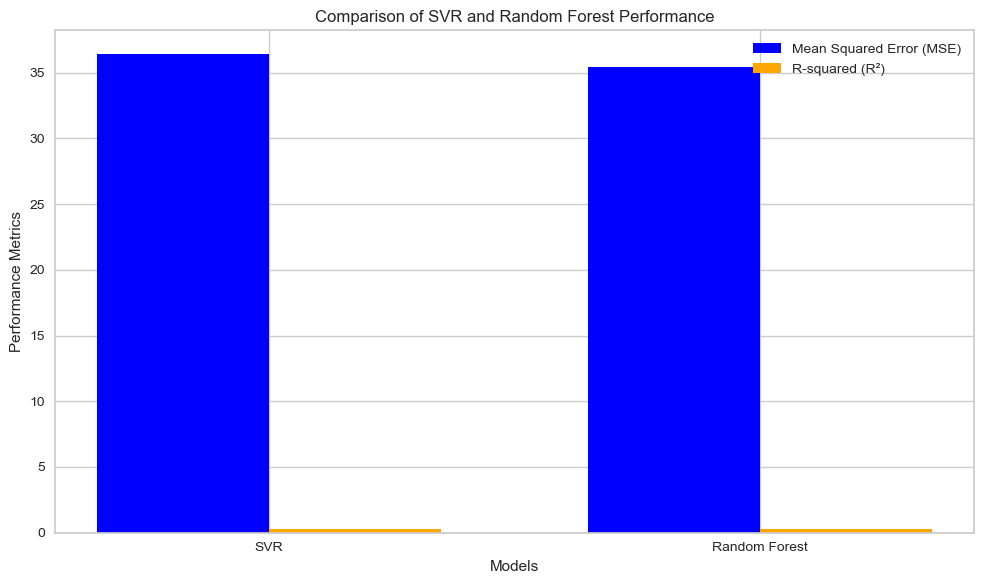

In [679]:
models = ['SVR', 'Random Forest']
mse_values = [mse_svr, mse_rf]
r2_values = [r2_svr, r2_rf]
x = np.arange(len(models))
bar_width = 0.35
plt.figure(figsize=(10, 6))

# Plot MSE bars
plt.bar(x - bar_width/2, mse_values, bar_width, label='Mean Squared Error (MSE)', color='blue')

# Plot R-squared bars
plt.bar(x + bar_width/2, r2_values, bar_width, label='R-squared (R²)', color='orange')
plt.xlabel('Models')
plt.ylabel('Performance Metrics')
plt.title('Comparison of SVR and Random Forest Performance')
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()

# Perform Clustering

In [681]:
df_cluster = df.copy()

- #### Kmeans Clustering Algorithm

In [683]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import MeanShift
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [684]:
df_cluster.drop(columns=['stroke'], inplace=True)
df_cluster.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [685]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster.values)
scaled_features_df = pd.DataFrame(scaled_features, index=df_cluster.index, columns=df_cluster.columns)

In [686]:
kmeans = KMeans(n_clusters=2, random_state=0)
clusters = kmeans.fit_predict(scaled_features_df)
df_cluster['Cluster'] = clusters

In [687]:
kmeans_silhouette = silhouette_score(scaled_features_df, kmeans.labels_).round(2)
print(f"Silhouette Score: {kmeans_silhouette}")

Silhouette Score: 0.2


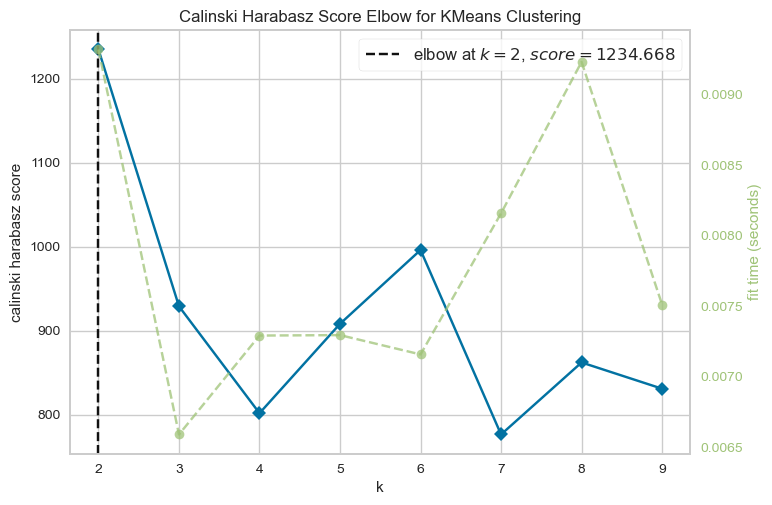

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [688]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2, 10), metric='calinski_harabasz')
visualizer.fit(scaled_features_df)        # Fit the data to the visualizer
visualizer.show()

C:\Users\hashi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


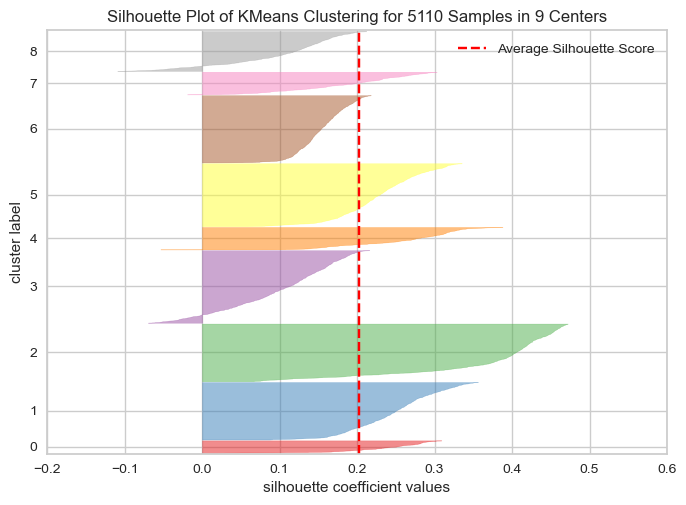

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 5110 Samples in 9 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [689]:
visualizer = SilhouetteVisualizer(model)
visualizer.fit(scaled_features_df)
visualizer.poof()

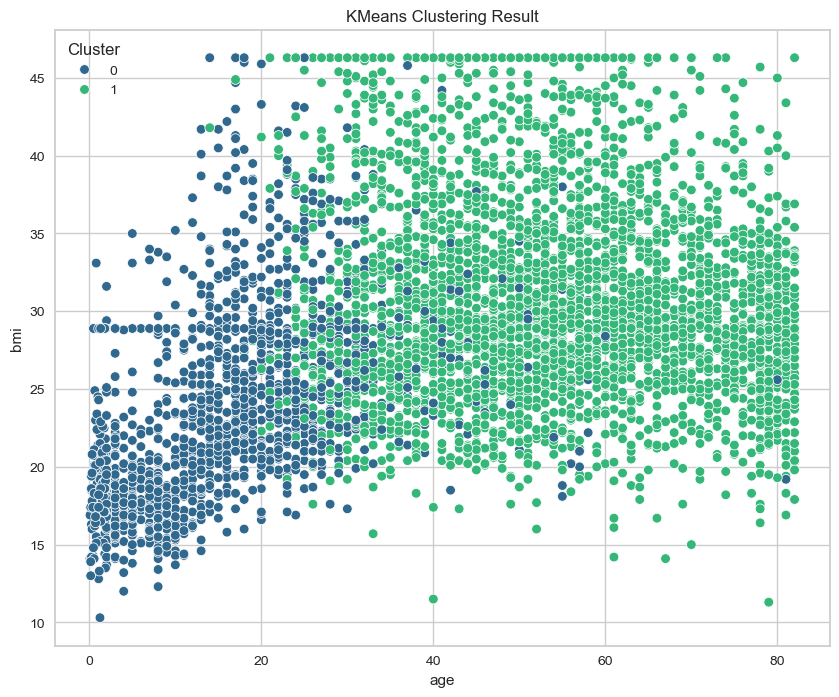

In [690]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='age', y='bmi', hue='Cluster', data=df_cluster, palette='viridis')
plt.title('KMeans Clustering Result')
plt.show()

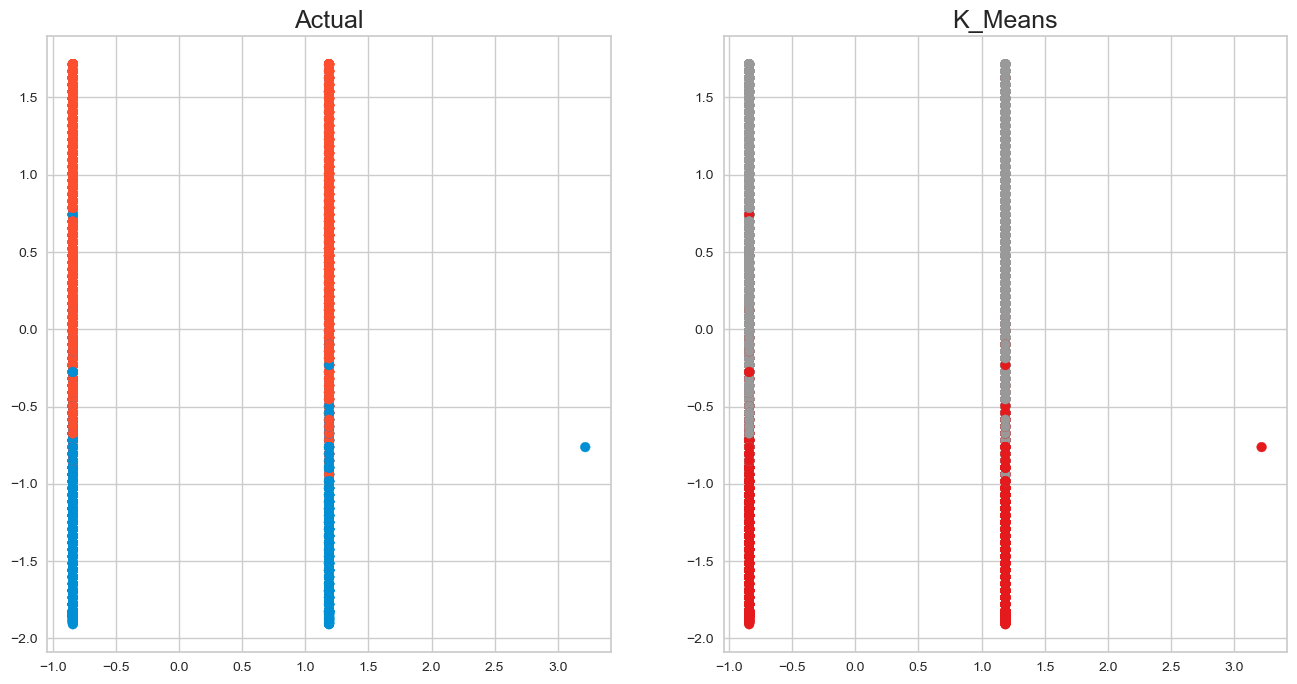

In [691]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fte_colors = {0: "#008fd5", 1: "#fc4f30"}
km_colors = [fte_colors[label] for label in kmeans.labels_]
axes[0].scatter(scaled_features_df.iloc[:, 0], scaled_features_df.iloc[:, 1], c=km_colors)
axes[1].scatter(scaled_features_df.iloc[:, 0], scaled_features_df.iloc[:, 1], c=kmeans.labels_, cmap=plt.cm.Set1)
axes[0].set_title('Actual', fontsize=18)
axes[1].set_title('K_Means', fontsize=18)
plt.show()

In [692]:
kmeans.labels_

array([1, 1, 1, ..., 1, 1, 1])

In [693]:
scaled_features_df['cluster'] = kmeans.labels_

In [694]:
cluster1 = scaled_features_df.query("cluster == 0")
cluster2 = scaled_features_df.query("cluster == 1")

In [695]:
cluster1.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,cluster
38,1.188073,0.653388,-0.328602,-0.238947,-1.381436,-0.153836,-1.016178,-0.252208,0.460497,-1.285114,0
118,-0.840344,-0.231159,-0.328602,-0.238947,-1.381436,0.763438,0.984080,-0.563546,-0.663218,-0.351781,0
162,-0.840344,-1.853419,-0.328602,-0.238947,-1.381436,1.680712,0.984080,-0.922157,0.024107,-1.285114,0
245,-0.840344,-1.292616,-0.328602,-0.238947,-1.381436,1.680712,-1.016178,-1.296726,0.305986,-1.285114,0
249,1.188073,-1.779117,-0.328602,-0.238947,-1.381436,1.680712,-1.016178,-0.176933,-1.506004,-1.285114,0


In [696]:
cluster1.shape

(1532, 11)

In [697]:
cluster1.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,cluster
count,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.000000,1532.0
mean,0.071914,-1.159357,-0.319798,-0.233171,-1.367694,0.641294,-0.022577,-0.234923,-0.673529,-0.499213,0.0
std,1.012060,0.537812,0.172122,0.159793,0.169593,1.016145,1.000434,0.761784,0.883693,0.988626,0.0
min,-0.840344,-1.908261,-0.328602,-0.238947,-1.381436,-1.988384,-1.016178,-1.381335,-2.587580,-1.285114,0.0
25%,-0.840344,-1.557980,-0.328602,-0.238947,-1.381436,-0.153836,-1.016178,-0.777026,-1.351494,-1.285114,0.0
50%,-0.840344,-1.204162,-0.328602,-0.238947,-1.381436,-0.153836,-1.016178,-0.379724,-0.831776,-1.285114,0.0
75%,1.188073,-0.850343,-0.328602,-0.238947,-1.381436,1.680712,0.984080,0.180248,-0.115407,0.581552,0.0
max,3.216489,1.670617,3.043196,4.185032,0.723884,1.680712,0.984080,2.058363,2.469137,1.514885,0.0


In [698]:
cluster2.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,cluster
0,1.188073,1.051434,-0.328602,4.185032,0.723884,-0.153836,0.984080,2.058363,1.106633,-0.351781,1
1,-0.840344,0.786070,-0.328602,-0.238947,0.723884,0.763438,-1.016178,2.058363,0.024107,0.581552,1
2,1.188073,1.626390,-0.328602,4.185032,0.723884,-0.153836,-1.016178,0.148256,0.530729,0.581552,1
3,-0.840344,0.255342,-0.328602,-0.238947,0.723884,-0.153836,0.984080,2.058363,0.797611,1.514885,1
4,-0.840344,1.582163,3.043196,-0.238947,0.723884,0.763438,-1.016178,2.058363,-0.663218,0.581552,1


In [699]:
cluster2.shape

(3578, 11)

In [700]:
cluster2.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,cluster
count,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.000000,3578.0
mean,-0.030792,0.496404,0.136929,0.099837,0.585609,-0.274584,0.009667,0.100587,0.288386,0.213749,1.0
std,0.993484,0.694705,1.163329,1.176600,0.521604,0.857363,0.999938,1.070716,0.903798,0.926176,0.0
min,-0.840344,-1.292616,-0.328602,-0.238947,-1.381436,-1.988384,-1.016178,-1.378324,-2.447116,-1.285114,1.0
25%,-0.840344,-0.054250,-0.328602,-0.238947,0.723884,-0.153836,-1.016178,-0.691439,-0.326104,-0.351781,1.0
50%,-0.840344,0.476478,-0.328602,-0.238947,0.723884,-0.153836,0.984080,-0.221345,0.109336,0.581552,1.0
75%,1.188073,1.051434,-0.328602,-0.238947,0.723884,-0.153836,0.984080,0.585906,0.797611,0.581552,1.0
max,1.188073,1.714845,3.043196,4.185032,0.723884,0.763438,0.984080,2.058363,2.469137,1.514885,1.0


In [701]:
kmeans.cluster_centers_

array([[ 0.07072445, -1.1571375 , -0.31980969, -0.2331789 , -1.36771202,
         0.64085538, -0.02387273, -0.23545568, -0.67190409, -0.49841256],
       [-0.03033873,  0.49637833,  0.13718906,  0.10002697,  0.58670868,
        -0.27490832,  0.01024071,  0.10100364,  0.28822731,  0.21380449]])

In [702]:
cluster1_mean = kmeans.cluster_centers_[0]
cluster2_mean = kmeans.cluster_centers_[1]

In [703]:
print("Cluster 1 Mean:\n", cluster1_mean)
print("Cluster 2 Mean:\n", cluster2_mean)

Cluster 1 Mean:
 [ 0.07072445 -1.1571375  -0.31980969 -0.2331789  -1.36771202  0.64085538
 -0.02387273 -0.23545568 -0.67190409 -0.49841256]
Cluster 2 Mean:
 [-0.03033873  0.49637833  0.13718906  0.10002697  0.58670868 -0.27490832
  0.01024071  0.10100364  0.28822731  0.21380449]


- #### Mean Shift Clustering algorithm

In [705]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster.values)

In [ ]:
mean_shift = MeanShift()
mean_shift.fit_predict(scaled_features)

In [ ]:
df_cluster['cluster'] = mean_shift.labels_

In [ ]:
df_cluster['cluster'].value_counts()

In [ ]:
cluster1 = df_cluster.query("cluster == 0")
cluster2 = df_cluster.query("cluster == 1")

In [ ]:
cluster1.head()

In [ ]:
cluster1.shape

In [ ]:
cluster1.describe()

In [ ]:
cluster2.head()

In [ ]:
cluster2.shape

In [ ]:
cluster2.describe()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_cluster.iloc[:, 0], df_cluster.iloc[:, 1], c=df_cluster['cluster'], cmap='viridis')
plt.title('Mean Shift Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()